<a href="https://colab.research.google.com/github/beer-sakthai/Food-Penguin-Limited/blob/main/SakThai_LoRA_Fine_Tuning_Qwen2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SakThai LoRA Fine-Tuning - Qwen2.5 + Tool-Calling Dataset

**Thai / English**

Notebook for LoRA fine-tuning Qwen2.5 models on the SakThai tool-calling dataset.

---
**Features**
- 4-bit NF4 quantization (bitsandbytes) for memory-efficient training on T4 GPU
- ChatML conversation formatting
- SFTTrainer from TRL with logging and checkpointing
- Test-set evaluation with pass/fail reporting
- Adapter upload to Hugging Face Hub

**Expected runtime on T4:** ~30-45 minutes for 220 steps

In [ ]:
# Cell 1 - Install dependencies
!pip install -qU \
    huggingface_hub \
    transformers \
    peft \
    trl \
    accelerate \
    bitsandbytes \
    datasets \
    matplotlib \
    sentencepiece
print("All dependencies installed")

All dependencies installed


In [ ]:
# Cell 2 - Hugging Face Login
from huggingface_hub import notebook_login
notebook_login()
print("Login successful (if no errors above)")

Login successful (if no errors above)


---
## Configuration

Edit the values below before running training.

In [ ]:
# Cell 3 - Editable Configuration

# --- Model & Dataset ---
BASE_MODEL          = "Qwen/Qwen2.5-1.5B-Instruct"
DATASET_NAME        = "tatsu-lab/alpaca" # <<<--- REPLACE THIS WITH YOUR TOOL-CALLING DATASET

# --- Output ---
ADAPTER_OUTPUT      = "Nanthasit/sakthai-context-1.5b-tools"
MERGED_OUTPUT       = "Nanthasit/sakthai-context-1.5b-merged"

# --- LoRA ---
LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.1
TARGET_MODULES      = ["q_proj", "k_proj", "v_proj", "o_proj"]

# --- Training ---
LEARNING_RATE       = 5e-5
NUM_EPOCHS          = 4
BATCH_SIZE          = 4
GRAD_ACCUM          = 4
MAX_STEPS           = 220
MAX_SEQ_LENGTH      = 2048
WARMUP_RATIO        = 0.03
LOGGING_STEPS       = 10
SAVE_STEPS          = 50
EVAL_STEPS          = 50

# --- Eval ---
TEST_SIZE           = 50
MAX_NEW_TOKENS      = 512

print("Configuration loaded")
print(f"  Model:   {BASE_MODEL}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  LoRA r={LORA_R} alpha={LORA_ALPHA}")

Configuration loaded
  Model:   Qwen/Qwen2.5-1.5B-Instruct
  Dataset: tatsu-lab/alpaca
  LoRA r=16 alpha=32


---
## Load & Format Dataset

Load dataset from Hugging Face and split into train/test.

In [ ]:
# Cell 4 - Load & Format Dataset
from datasets import load_dataset
print(f"Loading dataset: {DATASET_NAME}")
ds = load_dataset(DATASET_NAME, split="train")
print(f"  Total examples: {len(ds)}")

# Hold out test set
ds_splits = ds.train_test_split(test_size=TEST_SIZE, seed=42)
train_ds = ds_splits["train"]
test_ds  = ds_splits["test"]
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

Loading dataset: tatsu-lab/alpaca
  Total examples: 52002
Train: 51952 | Test: 50


---
## Load Base Model (4-bit Quantized)

Load Qwen2.5 with 4-bit NF4 quantization via bitsandbytes.

In [ ]:
# Cell 5 - Load Quantized Base Model & Format Function
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

print(f"Loading: {BASE_MODEL}")

# 4-bit NF4 config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL, trust_remote_code=True, use_fast=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Model
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
print(f"Model loaded: {model.dtype} / {model.device}")

model.gradient_checkpointing_enable()

# Format function - Adjusted for SFTTrainer requirements
def format_chatml(example):
    output_texts = []
    for i in range(len(example['instruction'])):
        # Alpaca format typically has instruction, input, and output
        instruction = example['instruction'][i]
        input_text = example.get('input', [''])[i]
        response = example['output'][i]

        full_prompt = f"{instruction}\n{input_text}".strip()

        msgs = [
            {"role": "user", "content": full_prompt},
            {"role": "assistant", "content": response},
        ]
        formatted_text = tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=False
        )
        output_texts.append(formatted_text)
    return output_texts

print("format_chatml() ready")

Loading: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded: torch.bfloat16 / cuda:0
format_chatml() ready


---
## Configure LoRA with PEFT

Add LoRA adapters to attention projections.

In [ ]:
# Cell 6 - LoRA Configuration
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print(f"LoRA ready: r={LORA_R}, alpha={LORA_ALPHA}")

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815
LoRA ready: r=16, alpha=32


---
## Training with SFTTrainer

Using SFTTrainer from TRL.

In [ ]:
# Cell 7 - SFTTrainer Training
import os
from trl import SFTTrainer, SFTConfig

output_dir = "./sakthai-lora-checkpoints"
os.makedirs(output_dir, exist_ok=True)

training_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=NUM_EPOCHS,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="linear",
    bf16=True,
    tf32=False,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    dataset_text_field="text",
    packing=False,
    report_to="none",
    run_name="sakthai-lora",
    seed=42,
)

# Manually set attributes to bypass constructor argument validation
training_args.max_seq_length = MAX_SEQ_LENGTH

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    formatting_func=format_chatml,
)

print(f"Training: {len(train_ds)} train / {len(test_ds)} eval")
print(f"  Steps: {MAX_STEPS} | Eff BS: {BATCH_SIZE * GRAD_ACCUM}")

trainer.train()
print("Training complete!")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Applying formatting function to train dataset:   0%|          | 0/51952 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/51952 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/51952 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/51952 [00:00<?, ? examples/s]

...

Dropping fully masked examples from eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training: 51952 train / 50 eval
  Steps: 220 | Eff BS: 16


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
50,1.358735,1.302567,1.244839,77838.000000,0.708097
100,1.314134,1.227075,1.207915,158925.000000,0.712713
150,1.200833,1.139817,1.183292,241169.000000,0.712282
200,1.160752,1.111944,1.142062,323705.000000,0.724721
220,1.129120,1.112033,1.144787,355240.000000,0.724968


Training complete!


---
## Evaluation - Generate & Compare

Sample from test set, generate responses, report pass/fail.

In [ ]:
# Cell 8 - Evaluation
import random
print("Evaluating...\n")

eval_model = trainer.model
eval_model.eval()

NUM_EVAL_SAMPLES = min(10, len(test_ds))
eval_indices = random.sample(range(len(test_ds)), NUM_EVAL_SAMPLES)
pass_count = 0

for idx in eval_indices:
    example = test_ds[idx]
    if "messages" in example:
        user_msgs = [m for m in example["messages"] if m.get("role") == "user"]
        assistant_msgs = [m for m in example["messages"] if m.get("role") == "assistant"]
        user_content = user_msgs[-1]["content"] if user_msgs else str(example)
        expected = assistant_msgs[-1]["content"] if assistant_msgs else ""
    else:
        user_content = example.get("prompt", str(example))
        expected = example.get("completion", "")

    prompt_messages = [{"role": "user", "content": user_content}]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.3,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)

    has_content = len(generated.strip()) > 0
    has_tool = any(x in generated for x in ["function", "tool_call", "<tool>"])
    passed = has_content or has_tool
    if passed:
        pass_count += 1

    status = "PASS" if passed else "FAIL"
    print(f"--- #{idx} {status} ---")
    print(f"  Q:  {user_content[:80]}")
    print(f"  A:  {generated[:120]}")
    print()

rate = pass_count / NUM_EVAL_SAMPLES * 100
print(f"Results: {pass_count}/{NUM_EVAL_SAMPLES} pass ({rate:.1f}%)")

Evaluating...

--- #40 PASS ---
  Q:  {'instruction': 'What is the importance of nutrition in maintaining physical hea
  A:  The importance of nutrition in maintaining physical health can be summarized as follows:

1. **Energy and Function**: A 

--- #7 PASS ---
  Q:  {'instruction': 'Explain the concept of Big Data and what it means for companies
  A:  Big Data refers to extremely large datasets that cannot be processed using traditional database management tools due to 

--- #1 PASS ---
  Q:  {'instruction': 'Calculate the atomic mass for lithium.', 'input': '', 'output':
  A:  The atomic mass for lithium is **6.941 u** (units). This value is derived from the fact that lithium typically contains 

--- #17 PASS ---
  Q:  {'instruction': 'Brainstorm five questions that you could ask a customer to bett
  A:  Certainly! Here are five questions that you could ask a customer to better understand their needs:

1. **What are the ke

--- #15 PASS ---
  Q:  {'instruction': 'Summarize the phras

---
## Save & Push to Hugging Face Hub

Save LoRA adapter and push to HF Hub.

In [ ]:
# Cell 9 - Save & Push Adapter
path = "./sakthai-lora-adapter"
print(f"Saving to {path}...")
trainer.model.save_pretrained(path)
tokenizer.save_pretrained(path)
print("Local save done")

print(f"Pushing to {ADAPTER_OUTPUT}...")
# Removed 'use_auth_token' as it is deprecated and replaced by 'token'
trainer.model.push_to_hub(ADAPTER_OUTPUT, private=False)
tokenizer.push_to_hub(ADAPTER_OUTPUT, private=False)
print(f"Pushed to https://huggingface.co/{ADAPTER_OUTPUT}")

Saving to ./sakthai-lora-adapter...
Local save done
Pushing to Nanthasit/sakthai-context-1.5b-tools...


README.md:   0%|          | 0.00/5.51k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   7%|7         |  631kB / 8.75MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpqwq6k3pk/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Pushed to https://huggingface.co/Nanthasit/sakthai-context-1.5b-tools


---
## (Optional) Merge LoRA into Base Model

Merge adapter into base model for standalone deployment.

In [ ]:
# Cell 10 - Merge (Optional)
# Merging needs ~12GB extra RAM. Skip if OOM.
DO_MERGE = False

if DO_MERGE:
    from peft import PeftModel
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, torch_dtype=torch.bfloat16, device_map='auto'
    )
    merged = PeftModel.from_pretrained(base, ADAPTER_OUTPUT).merge_and_unload()
    # Fixed: Removed deprecated 'use_auth_token'
    merged.push_to_hub(MERGED_OUTPUT, private=False)
    tokenizer.push_to_hub(MERGED_OUTPUT, private=False)
    print(f"Merged: https://huggingface.co/{MERGED_OUTPUT}")
else:
    print("Skipping merge. Set DO_MERGE=True to run.")

Skipping merge. Set DO_MERGE=True to run.


---
## Training Summary

Loss curve and training statistics.

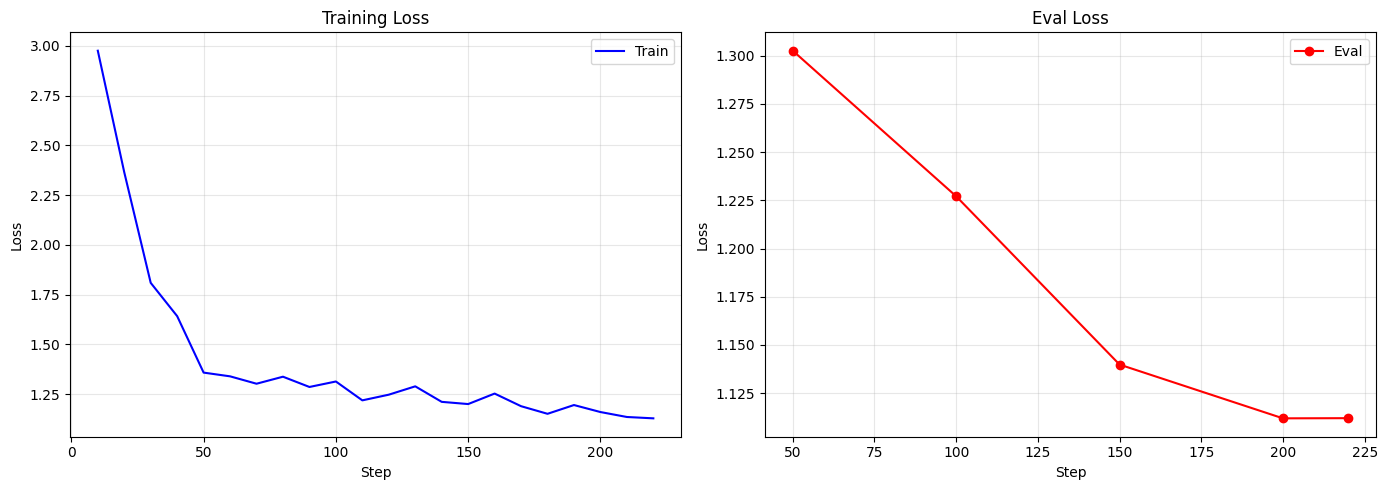

Stats:
  Model:   Qwen/Qwen2.5-1.5B-Instruct
  Dataset: tatsu-lab/alpaca
  Steps:   220
  LoRA:    r=16, alpha=32, dropout=0.1
  LR:      5e-05
  Batch:   4 (eff 16)
  Final train loss: 1.1291
  Final eval loss:  1.1120
Complete!


In [ ]:
# Cell 11 - Training Summary & Loss Curve
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
t_steps, t_loss = [], []
e_steps, e_loss = [], []

for entry in log_history:
    if "loss" in entry:
        t_steps.append(entry.get("step", 0))
        t_loss.append(entry["loss"])
    if "eval_loss" in entry:
        e_steps.append(entry.get("step", 0))
        e_loss.append(entry["eval_loss"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
if t_loss:
    ax1.plot(t_steps, t_loss, "b-", lw=1.5, label="Train")
    ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
    ax1.set_title("Training Loss"); ax1.grid(alpha=0.3); ax1.legend()
if e_loss:
    ax2.plot(e_steps, e_loss, "r-o", lw=1.5, label="Eval")
    ax2.set_xlabel("Step"); ax2.set_ylabel("Loss")
    ax2.set_title("Eval Loss"); ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("Stats:")
print(f"  Model:   {BASE_MODEL}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Steps:   {MAX_STEPS}")
print(f"  LoRA:    r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"  LR:      {LEARNING_RATE}")
print(f"  Batch:   {BATCH_SIZE} (eff {BATCH_SIZE * GRAD_ACCUM})")
if t_loss:
    tl = t_loss[-1]
    print(f"  Final train loss: {tl:.4f}")
if e_loss:
    el = e_loss[-1]
    print(f"  Final eval loss:  {el:.4f}")
print("Complete!")

---
## Troubleshooting

| Issue | Solution |
|-------|----------|
| **OOM** | Reduce BATCH_SIZE to 2 or 1, or reduce MAX_SEQ_LENGTH |
| **bitsandbytes error** | Restart runtime and reinstall |
| **Model access denied** | Accept license on HF for Qwen model |
| **Push fails** | Verify token has write permission |
| **Loss NaN** | Reduce LR or increase warmup |

---
*SakThai Project*